## House Prices - Advanced Regression Techniques <br> 房价——高级回归技术

### Goal 目标

It is your job to predict the sales price for each house. For each Id in the test set, you must predict the value of the SalePrice variable.
你的任务是预测每栋房屋的售价。对于测试集中的每个 ID，你必须预测 SalePrice 变量的值。

API key = KGAT_53788d07f5f72126b602b031635897c1

## 1 Packages and data load (5mins) 库与数据加载

- [x] Import packages
- [x] Set directories
- [x] Load dataset
- [x] Preview data

In [285]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.core.dtypes.common import is_numeric_dtype
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# config
sns.set_theme(style="whitegrid")

In [ ]:
DATA_DIR = Path(r"house-prices")

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
description_path = DATA_DIR / "data_description.txt"

print("当前目录:", DATA_DIR.resolve())
print("train.csv:", train_path.exists())
print("test.csv :", test_path.exists())
print("description:", description_path.exists())

In [ ]:
# NA_VALUES = []

train = pd.read_csv(train_path,keep_default_na=True) # na_values=NA_VALUES
test = pd.read_csv(test_path, keep_default_na=True) # na_values=NA_VALUES

In [ ]:
print("train shape:", train.shape)
print("test shape :", test.shape)

display(train.head())
display(test.head())

## 2 Data quality analysis (10 mins) 数据质量检查

- [x] Missing: missing count, missing rate
  缺失值异常：缺失数量、缺失率
- [x] Duplicated: duplicated rows, duplicated ids, duplicated entities
  重复异常：重复值、重复ID、重复实体
- [x] Outliers: distribution, extreme value
  离群异常：离群分布、极端值
- [x] Logic Inconsistent: time logic, quantity-existence, category-numeric, total-subtotal
  逻辑一致性异常：时间逻辑、数量和存在关系、类别和数值冲突、总量分量关系等
- [x] Invalidation: invalid range, invalid category, impossible value
  非法值异常：非法范围、非法类别等
- [ ] Formatting: case inconsistency, spacing, typos, empty strings, date/text format
  数据格式异常：拼写错误、大小写不一致、多余空格、空字符串等

### 2.1 Data understanding 数据理解

In [ ]:
print("--- ID/Target ---")
ID_COL = "Id"
TARGET_COL = "SalePrice"
print("Target:", TARGET_COL)
print("Target dtype:", train[TARGET_COL].dtype)

print("\n--- Columns Classify ---")
NUM_COL = train.select_dtypes(include=[np.number]).columns
OBJ_COL = train.select_dtypes(exclude=[np.number]).columns
print("Numerical Columns:", NUM_COL.tolist())
print("\nObjective Columns:", OBJ_COL.tolist())

print("\n--- train.info() ---")
print(train.info())

### 2.2 Missing value check 缺失值检查

- [x] missing count
- [x] missing rate

**注意：缺失值不一定代表错误。**

House Prices 中某些空值实际上可能意味着“没有该设施”，例如没有车库、地下室、泳池等。因此真正处理前应该阅读 `data_description.txt`。

| Missing rate | Handle strategy            |
|--------------|----------------------------|
| <0.1%        | 可以考虑直接删除对应行                |
| 0.1% ~ 5%    | 优先考虑简单填充                   |
| 5% ~ 30%     | 根据特征语义选择填充策略               |
| >30%         | 重点判断 NA 是否具有业务含义，不能仅凭缺失率决定 |

In [ ]:
def missing_report(
        df: pd.DataFrame,
        columns=None,
        missing_only=True,
        sort_by="missing_rate",
        ascending=False):

    if columns is not None:
        df = df[columns]

    # 生成缺失值报告表格
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_count": df.isna().sum(),
        "missing_rate": df.isna().mean()
    })

    # 过滤无缺失值的特征
    if missing_only:
        report = report[report["missing_count"] > 0]

    return report.sort_values(by=sort_by, ascending=ascending)

# 排序后输出
with pd.option_context("display.max_rows", None,"display.max_columns", None):
    display(missing_report(train))

### 2.3 Duplication check 重复值检查

- [x] 总重复行检查
- [x] ID 重复行检查
- [x] ID 部分缺失下的重复检查

In [ ]:
ID_COL = "Id"

print("Total duplicated rows:", train.duplicated().sum())

print("Duplicated rows num by Id:", train[ID_COL].duplicated(keep=False).sum())
print("Unique Id num:", train[ID_COL].nunique())
print("Total rows num:", len(train))

dup_ids = train.loc[train[ID_COL].duplicated(keep=False), ID_COL]
display(train[train[ID_COL].isin(dup_ids)].sort_values(ID_COL).head(20))


In [ ]:
# 自定义可唯一确定实体的 Columns 组合
# IDENTIFY_COLS = [
#     "Neighborhood",
#     "GrLivArea",
#     "YearBuilt",
#     "OverallQual"]

# 自定义不影响唯一实体确定的 Columns 组合
IDENTIFY_COLS_EXCLUDE = [
    ID_COL,
    TARGET_COL,
]
IDENTIFY_COLS = train.drop(columns=IDENTIFY_COLS_EXCLUDE).columns.tolist()

def duplicated_entities_report(
        df: pd.DataFrame,
        identify_columns=None):

    duplicated_mask = df.duplicated(subset=identify_columns, keep=False)

    duplicated_df = df.loc[duplicated_mask,identify_columns]
    duplicated_groups = (
        duplicated_df.groupby(identify_columns, dropna=False)
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )

    print("Duplicated entities:", len(duplicated_df))
    print("Duplicated groups:", len(duplicated_groups))

    return df[duplicated_mask][identify_columns].sort_values(identify_columns[0])

display(duplicated_entities_report(train, IDENTIFY_COLS))

### 2.4 Outliers check 离群值检查

- Numeric outlier
  - outlier count
  - outlier rate
- Categoric outlier
  - unique count
  - top frequency

In [ ]:
print("--- 数值变量统计 ---")
display(train.describe())

In [ ]:
# 离群值报告分析
def outlier_report(
        df: pd.DataFrame,
        cols,
        multiplier=1.5,
        sort_by="outlier_rate",):

    outliers = []
    for col in cols:
        if not is_numeric_dtype(df[col]): continue

        data = df[col].dropna()
        if len(data) == 0: continue

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - multiplier * IQR
        upper = Q3 + multiplier * IQR

        outlier_count = ((data < lower) | (data > upper)).sum()
        outlier_rate = outlier_count / len(data)

        outliers.append({
            "column": col,
            "count": len(data),
            "Q1": Q1,
            "Q3": Q3,
            "IQR": IQR,
            "lower": lower,
            "upper": upper,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_rate
        })

    report = pd.DataFrame(outliers).set_index("column")
    report.index.name = None

    report = report[report["outlier_count"] > 0]

    return report.sort_values(by=sort_by, ascending=False)

display(outlier_report(train, cols=NUM_COL.drop([ID_COL, TARGET_COL])).T)

In [ ]:
print("--- 类别变量统计 ---")
display(train.describe(exclude=[np.number]))
# display(train.describe(include=["object"]))

### 2.5 Logic Inconsistency/Invalid Value 逻辑不一致/非法值

- Date/time logic
- Quantity-existence
- Category-numeric
- Total-subtotal

In [ ]:
RULES = [
    ["Built year in future:", lambda df: df['YearBuilt'] > 2009],
]

def check_rule(df, rule, n_samples=5):

    name, condition = rule
    violations = df[condition]

    print(name, len(violations))

    if len(violations) > 0:
        display(violations.head(n_samples))

    return violations

for RULE in RULES:
    check_rule(train, RULE, len(train))

### 2.6 Format Issues

- dtype
- String Format
- Date/Time
- Spacing
- Encoding

In [ ]:
for col in OBJ_COL:
    print(col, train[col].nunique(), train[col].unique())

## 3 EDA/Statistical Analysis (15mins) 探索性数据统计分析

- [x] Target analysis
- [x] Numeric analysis
- [x] Categoric analysis
- [x] Correlative analysis

### 3.1 Target Analysis

- skewness 偏度
  - left skew <0: Power Transform, revert-Log Transform
  - right skew >0: Log Transform

Target Columns: SalePrice
Target skewness: 1.8828757597682129


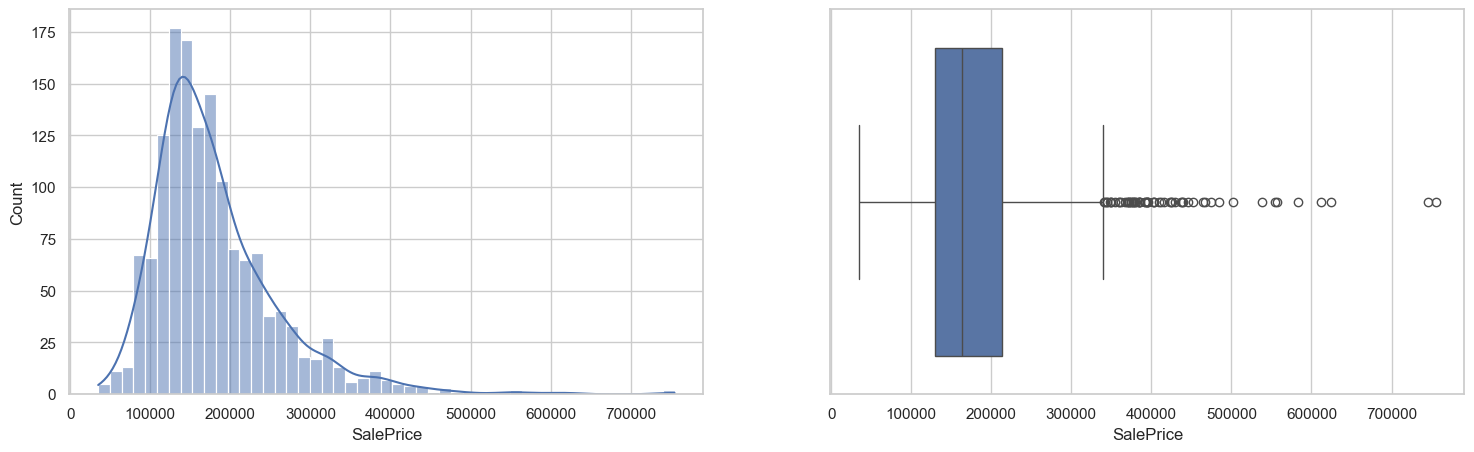

In [260]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

print("Target Columns:", TARGET_COL)
print("Target skewness:", train[TARGET_COL].skew())

sns.histplot(train[TARGET_COL], kde=True, ax=axes[0])
sns.boxplot(x=train[TARGET_COL], ax=axes[1])

plt.show()

### 3.2 Numeric analysis

- Distribution

In [ ]:
NUM_FEATURES = ['GrLivArea', 'EnclosedPorch']

def visual_analyse_numeric_feature(
        df: pd.DataFrame,
        num_features,
        target,
        rotation=0):

    for feature in num_features:
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

        print(feature)

        sns.scatterplot(x=df[feature],y=df[target], ax=axes[0])
        sns.histplot(df[feature], kde=True, ax=axes[1])
        sns.boxplot(x=df[feature], ax=axes[2])

        # subfig = plt.figure(figsize=(18, 5))
        # sns.boxplot(x=pd.cut(train[feature], bins=50, precision=1), y=train[TARGET_COL])
        # plt.xticks(rotation=90)
        # plt.show()

        for ax in axes:
            ax.tick_params(rotation=rotation)
        plt.show()
        plt.show()

visual_analyse_numeric_feature(train, NUM_FEATURES, TARGET_COL, rotation=0)

### 3.3 Categoric Analysis

- Distribution

In [ ]:
CAT_FEATURES = ['MSZoning']
# CAT_FEATURES = OBJ_COL

def visual_analyse_categoric_feature(
        df: pd.DataFrame,
        cat_features,
        target,
        rotation=0):
    for feature in cat_features:
        fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

        print(feature)

        sns.scatterplot(x=df[feature], y=df[target], ax=axes[0])
        sns.histplot(df[feature], kde=True, ax=axes[1])
        sns.boxplot(x=df[feature], y=df[target], ax=axes[2])

        for ax in axes:
            ax.tick_params(rotation=rotation)
        plt.show()

visual_analyse_categoric_feature(train, CAT_FEATURES, TARGET_COL)

### Correlative Analysis
- pearson
- spearman

In [ ]:
def visual_analyse_corr(
        features: pd.DataFrame,
        target,
        vmin=-1,
        vmax=1,
        annot=False,
        figsize=None,
):
    corr_pearson = features.corr(numeric_only=True,method="pearson")
    corr_spearman = features.corr(numeric_only=True,method="spearman")

    plt.figure(figsize=figsize)
    sns.heatmap(corr_pearson, vmin=vmin, vmax=vmax, annot=annot, square=True, cmap="coolwarm")
    plt.show()

    plt.figure(figsize=figsize)
    sns.heatmap(corr_spearman, vmin=vmin, vmax=vmax, annot=annot, square=True, cmap="coolwarm")
    plt.show()

    # display(corr_pearson[target].sort_values(ascending=False).head(10))
    # display(corr_spearman[target].sort_values(ascending=False).head(10))

visual_analyse_corr(train, TARGET_COL, figsize=(18, 18))

In [ ]:
def corr_report(
        features: pd.DataFrame,
        target,):

    corr_pearson = features.corr(numeric_only=True,method="pearson")
    corr_spearman = features.corr(numeric_only=True,method="spearman")

    # 2. Correlation with target
    target_corr_pearson = corr_pearson[target]
    target_corr_spearman = corr_spearman[target]

    target_corr = pd.DataFrame({
        "Pearson": target_corr_pearson,
        "Spearman": target_corr_spearman,
        "Differ": target_corr_pearson - target_corr_spearman
    })

    display(target_corr.sort_values(by="Spearman", ascending=False).head(10))
    display(target_corr.sort_values(by="Spearman", ascending=True).head(5))

corr_report(train, TARGET_COL)

## 4 Train/Valid Split(5 min)

In [ ]:
SELECTED_FEATURE = [
    "OverallQual",
    "OverallCond",

    "GrLivArea",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",

    "GarageCars",
    "GarageArea",

    "TotRmsAbvGrd",
    "BedroomAbvGr",
    "FullBath",

    "YearBuilt",
    "YearRemodAdd",

    "Neighborhood",

    "LotArea",
]

In [ ]:
X = train[SELECTED_FEATURE].copy()
Y = train[TARGET_COL].copy()

X_train, X_valid, Y_train, Y_valid = train_test_split(X, Y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("Y_train:", Y_train.shape)
print("Y_valid:", Y_valid.shape)
print(X_train.index.equals(Y_train.index))
print(X_valid.index.equals(Y_valid.index))

XY_train = pd.concat([X_train, Y_train], axis=1)
print(XY_train.shape)

display(X_train)
display(Y_train)

## 5 Feature Engineering (15 min) 特征工程

- Feature Selection
  - by correlation
  - by importance
- Feature Creation
- Feature Combination
  - Total/Sum/Count
- Feature Transformation
  - Log Transformation
  - Polynomial Transformation
  - Binning
- Feature Extraction
  - Date/Time Feature: Festival, Used time
  - Text Feature: description → vector(TF-IDF/embeddings)
  - Image Feature: pixel/color/shape


## 6 Preprocess (15 mins) 预处理

- Missing value handle: Numeric, Categoric
- Outlier handle: delete, replace, transform
- Feature Encoding
  - One-Hot Encoding
  - Ordinal Encoding
- Feature Scaling
  - Standardization: mean → 0, std → 1
  - Normalization: value → [0~1]

In [282]:
NUM_X_TRAIN_FEATURES = X_train.select_dtypes(
    include="number"
).columns.tolist()

CAT_X_TRAIN_FEATURES = X_train.select_dtypes(
    exclude="number"
).columns.tolist()

print("Numerical:", NUM_X_TRAIN_FEATURES)
print("\nCategorical:", CAT_X_TRAIN_FEATURES)

Numerical: ['OverallQual', 'OverallCond', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GarageCars', 'GarageArea', 'TotRmsAbvGrd', 'BedroomAbvGr', 'FullBath', 'YearBuilt', 'YearRemodAdd', 'LotArea']

Categorical: ['Neighborhood']


### 6.1 Missing Value Handle
No missing value, no need to handle

In [ ]:
print("Missing report of X_Train:")
display(missing_report(X_train, columns=SELECTED_FEATURE))

### 6.2 Duplicated Value Handle
No global duplicated entity, no need to handle

In [ ]:
print("Duplicated report by id columns of Train:")
display(duplicated_entities_report(train, [ID_COL]))

print("Duplicated report by identify columns of Train:")
display(duplicated_entities_report(train, IDENTIFY_COLS))

### 6.3 Outlier Handle
Basically normal, no need to handle

In [257]:
print("Outliers report of selected features:")
display(outlier_report(XY_train, XY_train.columns.tolist()))

Outliers report of selected features:


,count,Q1,Q3,IQR,lower,upper,outlier_count,outlier_rate
OverallCond,1168,5.00,6.00,1.00,3.500,7.500,99,0.084760
LotArea,1168,7587.25,11700.00,4112.75,1418.125,17869.125,54,0.046233
SalePrice,1168,130000.00,214925.00,84925.00,2612.500,342312.500,48,0.041096
TotalBsmtSF,1168,796.00,1299.25,503.25,41.125,2054.125,47,0.040240
BedroomAbvGr,1168,2.00,3.00,1.00,0.500,4.500,26,0.022260
TotRmsAbvGrd,1168,5.00,7.00,2.00,2.000,10.000,25,0.021404
GrLivArea,1168,1145.75,1792.00,646.25,176.375,2761.375,23,0.019692
GarageArea,1168,341.00,576.00,235.00,-11.500,928.500,18,0.015411
1stFlrSF,1168,888.00,1396.75,508.75,124.875,2159.875,13,0.011130
YearBuilt,1168,1953.00,2001.00,48.00,1881.000,2073.000,5,0.004281


### 6.4 Logic Consistency Handle

No logic consistency, no need to handle

In [258]:
print("Logic inconsistency check of selected features:")
TRAIN_RULES = [
    ["Built year in future:", lambda df: df['YearBuilt'] > 2010],
    ["Built year later than RemodAdd", lambda df: df['YearBuilt'] > df['YearRemodAdd']],
]
for RULE in TRAIN_RULES:
    check_rule(X_train, RULE)

Logic inconsistency check of selected features:
Built year in future: 0
Built year later than RemodAdd 0


### 6.5 Categoric Encode
- One-Hot Encoding: for nominal categorical feature

In [259]:
for col in CAT_X_TRAIN_FEATURES:
    print(col, train[col].nunique(), train[col].unique())

Neighborhood 25 ['CollgCr' 'Veenker' 'Crawfor' 'NoRidge' 'Mitchel' 'Somerst' 'NWAmes'
 'OldTown' 'BrkSide' 'Sawyer' 'NridgHt' 'NAmes' 'SawyerW' 'IDOTRR'
 'MeadowV' 'Edwards' 'Timber' 'Gilbert' 'StoneBr' 'ClearCr' 'NPkVill'
 'Blmngtn' 'BrDale' 'SWISU' 'Blueste']


### 6.6 Target Skew

Target skewness: 1.743128561420854


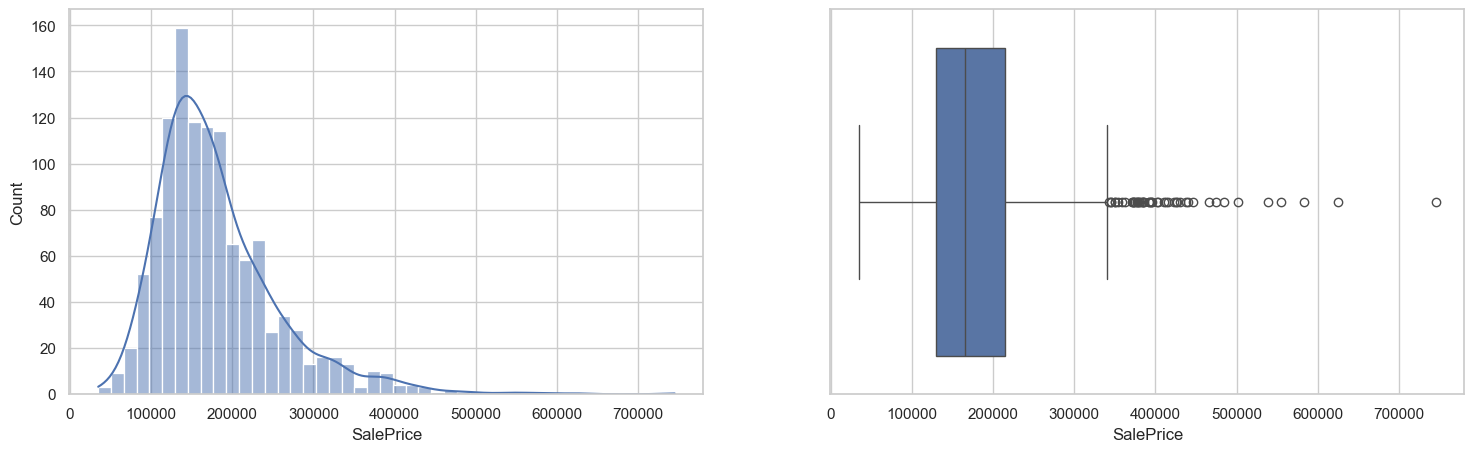

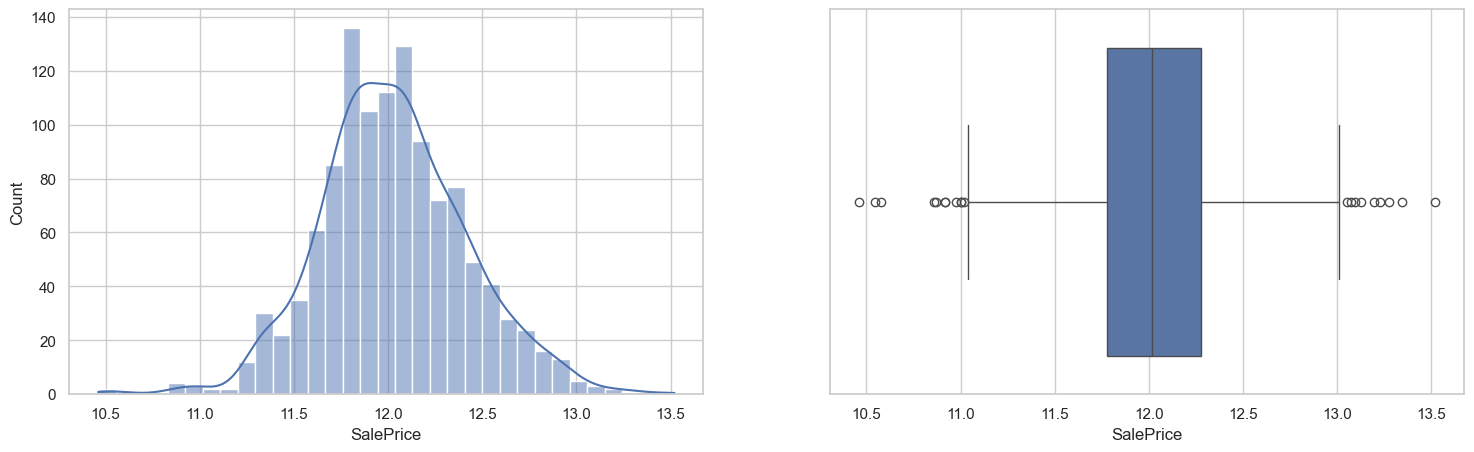

In [278]:
print("Target skewness:", Y_train.skew())

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

sns.histplot(Y_train, kde=True, ax=axes[0])
sns.boxplot(x=Y_train, ax=axes[1])

Y_train_log = np.log(Y_train)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

sns.histplot(Y_train_log, kde=True, ax=axes[0])
sns.boxplot(x=Y_train_log, ax=axes[1])

plt.show()

### 6.6 Pipeline

In [286]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, NUM_X_TRAIN_FEATURES),
    ("cat", categorical_transformer, CAT_X_TRAIN_FEATURES),
])

In [ ]:
visual_analyse_numeric_feature(XY_train, NUM_X_TRAIN_FEATURES ,TARGET_COL)

In [ ]:
visual_analyse_categoric_feature(XY_train, CAT_X_TRAIN_FEATURES, TARGET_COL, rotation=90)

In [ ]:
visual_analyse_corr(XY_train, TARGET_COL)

In [ ]:
corr_report(XY_train, TARGET_COL)

## 7 Model Training (30 mins) 模型训练

- Baseline model Select
  - Regression: LinealRegression, GradientBoost
- Model Training
- Valid Predict

In [301]:
linear_model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])

linear_model.fit(X_train, Y_train_log)
linear_pred_log = linear_model.predict(X_valid)

linear_pred = np.exp(linear_pred_log)

print("Y_valid:", Y_valid.shape)
print("linear_pred:", linear_pred.shape)

Y_valid: (292,)
linear_pred: (292,)


In [302]:
result_df = pd.DataFrame({
    "actual": Y_valid,
    "predicted": linear_pred,
    "error": Y_valid-linear_pred,
    "error_rate": (Y_valid-linear_pred)/Y_valid
})

display(result_df)

,actual,predicted,error,error_rate
892,154500,155909.231633,-1409.231633,-0.009121
1105,325000,306553.926985,18446.073015,0.056757
413,115000,110198.897047,4801.102953,0.041749
522,159000,162180.973900,-3180.973900,-0.020006
1036,315500,285336.923925,30163.076075,0.095604
...,...,...,...,...
479,89471,121391.649685,-31920.649685,-0.356771
1361,260000,251353.162073,8646.837927,0.033257
802,189000,190357.463671,-1357.463671,-0.007182
651,108000,103858.143660,4141.856340,0.038351


## 8 Evaluation (10 mins) 评估指标

In [303]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

mae = mean_absolute_error(
    Y_valid,
    linear_pred,
)

rmse = mean_squared_error(
    Y_valid,
    linear_pred,
) ** 0.5

r2 = r2_score(
    Y_valid,
    linear_pred,
)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

MAE : 18052.72
RMSE: 28377.80
R²  : 0.8950


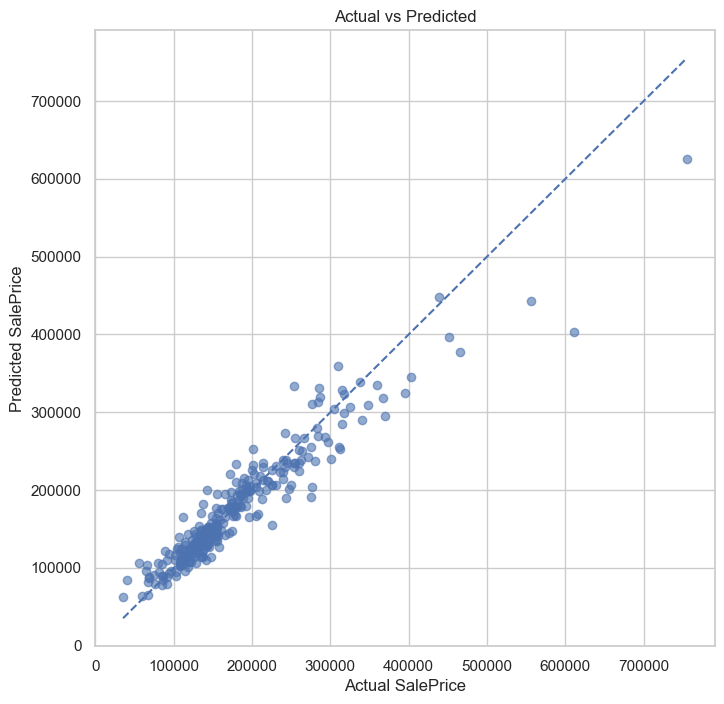

In [304]:
plt.figure(figsize=(8, 8))

plt.scatter(
    Y_valid,
    linear_pred,
    alpha=0.6,
)

plt.plot(
    [Y_valid.min(), Y_valid.max()],
    [Y_valid.min(), Y_valid.max()],
    linestyle="--",
)

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted")

plt.show()

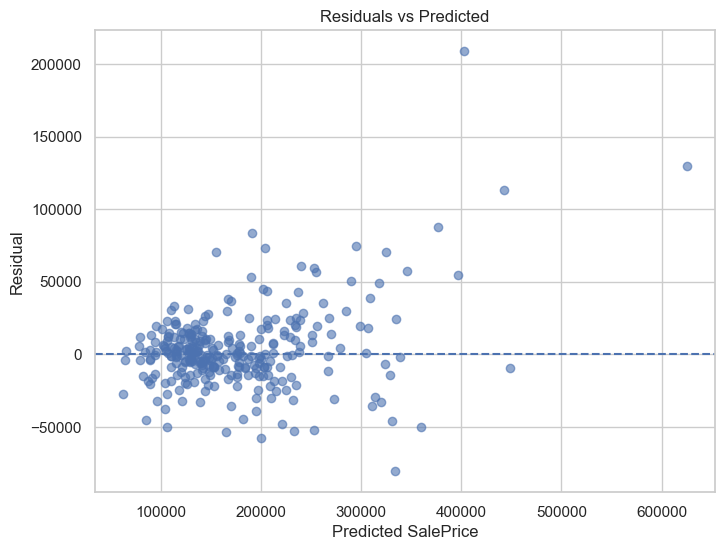

In [306]:
plt.figure(figsize=(8, 6))

residuals = Y_valid - linear_pred

plt.scatter(
    linear_pred,
    residuals,
    alpha=0.6,
)

plt.axhline(
    0,
    linestyle="--",
)

plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted")

plt.show()

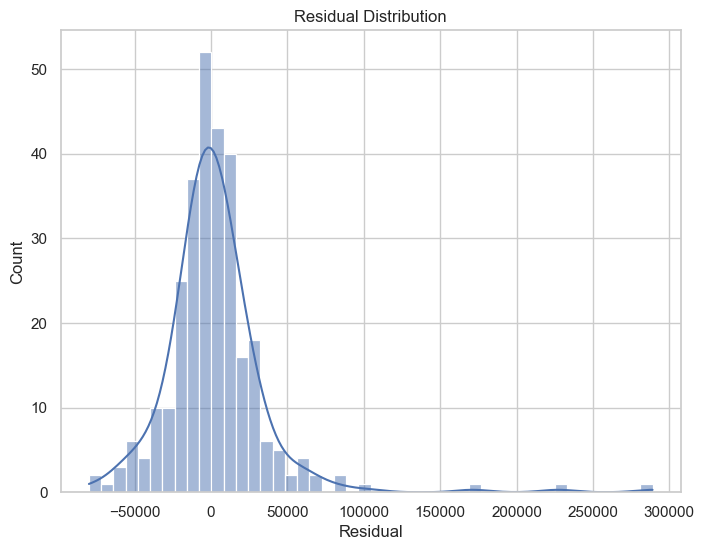

In [298]:
plt.figure(figsize=(8, 6))

sns.histplot(
    residuals,
    kde=True,
)

plt.xlabel("Residual")
plt.title("Residual Distribution")

plt.show()

## 9 Conclution

